## OncoChat – Full Training Pipeline

**Models:** RVIT | HONeYBEE | MUSK | OncoChat | OncoNPC

**Data:** DatasetDiagnosis_Imagereport.csv (80/20 split)

**Evaluation:** Accuracy, Precision, Recall, F1, MCC, Sensitivity, Specificity, P-values, Confusion Matrix

### 0. Imports

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, matthews_corrcoef)
from scipy import stats
from transformers import AutoTokenizer, AutoModel
warnings.filterwarnings("ignore")

c:\Users\cbe\Desktop\Cancer_tumor\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# pip install transformers

### 1. Load & Prepare Data (80/20 split)

In [3]:
df = pd.read_csv(
    'C:/Users/cbe/Desktop/Cancer_tumor/Text Datasets/DatasetDiagnosis_Imagereport.csv',
    encoding='ISO-8859-1'
)
df

,Unnamed: 0,MRN,Age,Sex,Occupation,Region,Zone,City,SubCity,Woreda,...,Is Available,HistoryType,History value,Prescrption Type,Prescribed Item,Residence,Tumor_Type,Stage,Education_Level,Imagereport
0,0,272161.0,50.0,Male,Self employee,"Southern Nations, Nationalities and Peoples",Gurage,Welkite,NaN,Welkite,...,1.0,HISTORY,Known cardiac pt on follow up on atenolol 25mg...,Prescription,"{""Name"":""paracetamol"",""Strength"":""10mg"",""Presc...",rural,Malignant,stage3,Illiterate,There is calcification at the bifurcation of t...
1,1,271933.0,45.0,Female,Self employee,Oromia,Oromia-Finfinne,BURAYU,NaN,BURAYU,...,1.0,HISTORY,c/c: BACK PAIN/01 month 45yrs old female pati...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""CEFTRIAXO...",rural,Malignant,stage3,Illiterate,The nodules show heterogenous enhancement on p...
2,2,272272.0,51.0,Female,Self employee,Addis Ababa,Addis Ababa,Addis Ababa,Yeka,1,...,1.0,HISTORY,P/E H.E.E.N.T: pink conjuctivae and NICS LGS:...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""PLASILE 1...",urban,Malignant,stage3,Illiterate,There is a diffuse enlargement of the thyroid ...
3,3,272380.0,72.0,Female,Self employee,Benshangul-Gumaz,Asosa,Asosa,NaN,Asosa,...,0.0,HISTORY,he is a 19 year old patient who had followup a...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""GLOVE "",""...",rural,Malignant,stage3,Primary Education,Upper abdomen: All the included solid upper ab...
4,4,267125.0,60.0,Male,Self employee,"Southern Nations, Nationalities and Peoples",Gurage,GURAGE,NaN,ENDGJE,...,0.0,HISTORY,Known HTN with HHD and polycythemia pt and B.A...,Prescription,"{""PrescriptionType"":""Medication"",""Name"":""Olanz...",rural,Malignant,stage3,Illiterate,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19719,19719,10222.0,21.0,Male,NaN,NaN,NaN,NaN,KIRKOS,NaN,...,0.0,HISTORY,P: MDD + Conversion d/o Rx: Flouxetine 20mg PO...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""amoxacill...",rural,Benign,stage2,Unknown,NaN
19720,19720,160158.0,29.0,Female,NaN,Addis Ababa,Addis Ababa,Addis Ababa,Kolfe,3,...,0.0,HISTORY,GDM + LATE 2ND TMP ON DIATERY MODIFICATION S...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""ns"",""Stre...",urban,Benign,stage2,Unknown,NaN
19721,19721,NaN,NaN,NaN,farmer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stage2,Unknown,NaN
19722,19722,NaN,NaN,NaN,Self_employes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stage2,Unknown,NaN


In [4]:
df.drop(['Zone'],axis=1, inplace=True)
df.drop(['City'],axis=1, inplace=True)
df.drop(['SubCity'],axis=1, inplace=True)
df.drop(['Woreda'],axis=1, inplace=True)
df.drop(['Kebel'],axis=1, inplace=True)
df.drop(['Is Available'],axis=1, inplace=True)
df.drop(['Is Paid'],axis=1, inplace=True)
df.drop(['Unit'],axis=1, inplace=True)
df.drop(['Price'],axis=1, inplace=True)
# df.drop(['Stage'],axis=1, inplace=True)
df.drop(['Unnamed: 0'],axis=1, inplace=True)

In [5]:
# Replace entries in 'Imagereport' column with 'no image report/report' if there's no data in the cell
df['Imagereport'] = df['Imagereport'].apply(lambda x: 'no image report/report' if pd.isna(x) or x == '' else x)
df

,MRN,Age,Sex,Occupation,Region,Diagnosis,Group diagonsis,Type diagnosis,Status,Date,...,Laboratory Service,HistoryType,History value,Prescrption Type,Prescribed Item,Residence,Tumor_Type,Stage,Education_Level,Imagereport
0,272161.0,50.0,Male,Self employee,"Southern Nations, Nationalities and Peoples",Malignant neoplasm of rectum,Primary Diagnosis,Presumptive,Active,1/22/2024,...,CT Abdomen,HISTORY,Known cardiac pt on follow up on atenolol 25mg...,Prescription,"{""Name"":""paracetamol"",""Strength"":""10mg"",""Presc...",rural,Malignant,stage3,Illiterate,There is calcification at the bifurcation of t...
1,271933.0,45.0,Female,Self employee,Oromia,"Malignant neoplasm of liver, primary, unspecif...",Primary Diagnosis,Presumptive,Active,1/22/2024,...,CT Angiography with Contrast,HISTORY,c/c: BACK PAIN/01 month 45yrs old female pati...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""CEFTRIAXO...",rural,Malignant,stage3,Illiterate,The nodules show heterogenous enhancement on p...
2,272272.0,51.0,Female,Self employee,Addis Ababa,Malignant neoplasm of exocervix,Primary Diagnosis,Presumptive,Active,1/22/2024,...,CT Chest,HISTORY,P/E H.E.E.N.T: pink conjuctivae and NICS LGS:...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""PLASILE 1...",urban,Malignant,stage3,Illiterate,There is a diffuse enlargement of the thyroid ...
3,272380.0,72.0,Female,Self employee,Benshangul-Gumaz,Malignant neoplasm of exocervix,Primary Diagnosis,Presumptive,Active,1/22/2024,...,CT Angiography with Contrast,HISTORY,he is a 19 year old patient who had followup a...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""GLOVE "",""...",rural,Malignant,stage3,Primary Education,Upper abdomen: All the included solid upper ab...
4,267125.0,60.0,Male,Self employee,"Southern Nations, Nationalities and Peoples",Malignant neoplasm of body of stomach,Primary Diagnosis,Presumptive,Active,1/22/2024,...,HBsAg,HISTORY,Known HTN with HHD and polycythemia pt and B.A...,Prescription,"{""PrescriptionType"":""Medication"",""Name"":""Olanz...",rural,Malignant,stage3,Illiterate,no image report/report
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19719,10222.0,21.0,Male,NaN,NaN,Polycythemia vera,Primary Diagnosis,Presumptive,Active,8/4/2022,...,New Patient Registration,HISTORY,P: MDD + Conversion d/o Rx: Flouxetine 20mg PO...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""amoxacill...",rural,Benign,stage2,Unknown,no image report/report
19720,160158.0,29.0,Female,NaN,Addis Ababa,"Diffuse follicle center lymphoma, lymph nodes ...",Primary Diagnosis,Presumptive,Active,8/4/2022,...,Patient Registration Renewal,HISTORY,GDM + LATE 2ND TMP ON DIATERY MODIFICATION S...,Prescription,"{""PrescriptionType"":""Supply"",""Name"":""ns"",""Stre...",urban,Benign,stage2,Unknown,no image report/report
19721,NaN,NaN,NaN,farmer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stage2,Unknown,no image report/report
19722,NaN,NaN,NaN,Self_employes,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stage2,Unknown,no image report/report


In [6]:
# Identify numeric columns
numeric_col = df.select_dtypes(include=['number', 'float']).columns.tolist()

# Identify categorical columns
categorical_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Print the lists
print("Numeric columns:", numeric_col)
print("Categorical columns:", categorical_col)


Numeric columns: ['MRN', 'Age']
Categorical columns: ['Sex', 'Occupation', 'Region', 'Diagnosis', 'Group diagonsis', 'Type diagnosis', 'Status', 'Date', 'Pacient Weight', 'BMI', 'Laboratory Service ', 'HistoryType', 'History value ', 'Prescrption Type', 'Prescribed Item', 'Residence', 'Tumor_Type', 'Stage', 'Education_Level', 'Imagereport']


In [7]:
Categorical_col=['Sex', 'Occupation', 'Region', 'Zone', 'City', 'SubCity', 'Woreda', 'Kebel', 'Diagnosis', 'Group diagonsis', 'Type diagnosis', 'Status', 'Date', 'Unit', 'Pacient Weight', 'BMI', 'Laboratory Service ', 'HistoryType', 'History value ', 'Prescrption Type', 'Prescribed Item', 'Residence', 'Tumor_Type', 'Stage', 'Education_Level', 'Imagereport']

In [8]:
Numeric_col=['MRN', 'Age', 'Price', 'Is Paid', 'Is Available']

In [9]:
def fill_missing_values(df, method='mode'):
    """
    Fill missing values in categorical columns using the specified method.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to process.
    method (str): The method to fill missing values ('mode', 'ffill', 'bfill', 'constant', 'least_frequent', 'interpolate').
    
    Returns:
    pd.DataFrame: The DataFrame with missing values filled.
    """
    for column in df.select_dtypes(include=['object', 'category']).columns:
        if method == 'mode':
            mode_value = df[column].mode()[0]
            df[column].fillna(mode_value, inplace=True)
        elif method == 'ffill':
            df[column].fillna(method='ffill', inplace=True)
        elif method == 'bfill':
            df[column].fillna(method='bfill', inplace=True)
        elif method == 'constant':
            df[column].fillna('Unknown', inplace=True)
        elif method == 'least_frequent':
            least_frequent = df[column].value_counts().idxmin()
            df[column].fillna(least_frequent, inplace=True)
        elif method == 'interpolate' and df[column].dtype.name == 'category':
            # Convert to ordered categorical and interpolate
            df[column] = df[column].cat.add_categories('Missing')
            df[column].fillna('Missing', inplace=True)
            df[column] = df[column].cat.codes.replace(-1, pd.NA).interpolate().astype(int)
            df[column] = pd.Categorical.from_codes(df[column], categories=df[column].cat.categories)
    
    return df

def process_excel_file(file_path, method='mode'):
    """
    Process an Excel file to fill missing values in categorical columns.
    
    Parameters:
    file_path (str): The path to the Excel file.
    method (str): The method to fill missing values ('mode', 'ffill', 'bfill', 'constant', 'least_frequent', 'interpolate').
    
    Returns:
    pd.DataFrame: The processed DataFrame.
    """
    # # Read the Excel file
    # df = pd.read_excel(file_path)
    
    # Fill missing values
    df_filled = fill_missing_values(df, method=method)
    
    return df_filled

# Example usage:
file_path = 'path_to_your_excel_file.xlsx'
method = 'mode'  # You can change this to 'ffill', 'bfill', 'constant', 'least_frequent', or 'interpolate'

# Process the Excel file and get the filled DataFrame
filled_df = process_excel_file(file_path, method=method)

In [10]:
import pandas as pd
from sklearn.impute import KNNImputer

def fill_missing_numeric_values(df, method='mean', n_neighbors=5):
    """
    Fill missing values in numeric columns using the specified method.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to process.
    method (str): The method to fill missing values ('mean', 'median', 'mode', 'ffill', 'bfill', 'constant', 'knn').
    n_neighbors (int): Number of neighboring samples to use for KNN imputation (used only if method='knn').
    
    Returns:
    pd.DataFrame: The DataFrame with missing values filled.
    """
    for column in df.select_dtypes(include=['number']).columns:
        if method == 'mean':
            df[column].fillna(df[column].mean(), inplace=True)
        elif method == 'median':
            df[column].fillna(df[column].median(), inplace=True)
        elif method == 'mode':
            df[column].fillna(df[column].mode()[0], inplace=True)
        elif method == 'ffill':
            df[column].fillna(method='ffill', inplace=True)
        elif method == 'bfill':
            df[column].fillna(method='bfill', inplace=True)
        elif method == 'constant':
            df[column].fillna(0, inplace=True)  # Replace 0 with any constant value you prefer
        elif method == 'knn':
            imputer = KNNImputer(n_neighbors=n_neighbors)
            df[df.select_dtypes(include=['number']).columns] = imputer.fit_transform(df.select_dtypes(include=['number']))
    
    return df

def process_excel_file(file_path, method='mean', n_neighbors=5):
    """
    Process an Excel file to fill missing values in numeric columns.
    
    Parameters:
    file_path (str): The path to the Excel file.
    method (str): The method to fill missing values ('mean', 'median', 'mode', 'ffill', 'bfill', 'constant', 'knn').
    n_neighbors (int): Number of neighboring samples to use for KNN imputation (used only if method='knn').
    
    Returns:
    pd.DataFrame: The processed DataFrame.
    """
    # # Read the Excel file
    # df = pd.read_excel(file_path)
    
    # Fill missing values in numeric columns
    df_filled = fill_missing_numeric_values(df, method=method, n_neighbors=n_neighbors)
    
    return df_filled

# Example usage:
file_path = 'path_to_your_excel_file.xlsx'
method = 'knn'  # You can change this to 'mean', 'median', 'mode', 'ffill', 'bfill', 'constant', or 'knn'
n_neighbors = 5  # Number of neighbors for KNN imputation

# Process the Excel file and get the filled DataFrame
filled_df = process_excel_file(file_path, method=method, n_neighbors=n_neighbors)

In [11]:
# Train, Test and for valdiuatiopn use CV 
df.isnull().sum()

MRN                        0
Age                        0
Sex                        3
Occupation             19506
Region                   908
Diagnosis                  3
Group diagonsis            3
Type diagnosis             3
Status                     3
Date                       3
Pacient Weight             3
BMI                        8
Laboratory Service         3
HistoryType                3
History value              6
Prescrption Type           3
Prescribed Item            3
Residence                  3
Tumor_Type                 3
Stage                      0
Education_Level            0
Imagereport                0
dtype: int64

In [12]:
# ── Shared Evaluation Utilities ───────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, matthews_corrcoef)
from scipy import stats

def compute_metrics(y_true, y_pred, loss=None, y_prob=None):
    """Compute comprehensive evaluation metrics."""
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_true": y_true,  # Store for ROC
        "y_prob": y_prob if y_prob is not None else None,  # Store for ROC
    }
    
    # Per-class sensitivity and specificity
    cm = m["confusion_matrix"]
    sensitivity = {}
    specificity = {}
    n_classes = len(cm)
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity[i] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity[i] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    m["sensitivity"] = sensitivity
    m["specificity"] = specificity
    
    if loss is not None:
        m["loss"] = loss
    return m


def print_metrics(name, m):
    """Pretty print metrics for a model."""
    print(f"\n{'='*60}")
    print(f"  {name} – Final Test Metrics")
    print(f"{'='*60}")
    print(f"  Accuracy:  {m['accuracy']:.4f}")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  Recall:    {m['recall']:.4f}")
    print(f"  F1:        {m['f1']:.4f}")
    print(f"  MCC:       {m['mcc']:.4f}")
    if 'loss' in m:
        print(f"  Loss:      {m['loss']:.4f}")
    print(f"{'─'*60}")
    print("  Confusion Matrix:")
    print(m["confusion_matrix"])
    print(f"{'='*60}")

### 2. Shared Evaluation Utilities

In [13]:
# ── Handle Missing Values + Train/Test Split ─────────────────────────────────
from sklearn.model_selection import StratifiedKFold, train_test_split

# First: Handle missing values according to data types
# Numeric columns → median
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical/object columns → mode
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna('Unknown')

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

# Now split into features and target
X = df.drop(columns=['Tumor_Type'])
y = df['Tumor_Type']

# Split into train (80%) and test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5-Fold Stratified Cross-Validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nFull dataset: {len(X)} samples")
print(f"Train (for CV): {len(X_train_full)} samples ({len(X_train_full)/len(X)*100:.1f}%)")
print(f"Test (holdout): {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nCross-validation: {cv.n_splits} folds on training set")
print(f"Target distribution in train:\n{y_train_full.value_counts()}")
print(f"Target distribution in test:\n{y_test.value_counts()}")

Missing values after cleaning: 0

Full dataset: 19724 samples
Train (for CV): 15779 samples (80.0%)
Test (holdout): 3945 samples (20.0%)

Cross-validation: 5 folds on training set
Target distribution in train:
Tumor_Type
Benign       8520
Malignant    7259
Name: count, dtype: int64
Target distribution in test:
Tumor_Type
Benign       2130
Malignant    1815
Name: count, dtype: int64


### 3. RVIT – Rotation-Invariant Vision Transformer

In [14]:
# ── 3. RVIT (Rotation-Invariant Vision Transformer) ──────────────────────────
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.projection = nn.Sequential(
            Rearrange("b c (h p1) (w p2) -> b (h w) (p1 p2 c)", p1=patch_size, p2=patch_size),
            nn.Linear(patch_size * patch_size * in_channels, embed_dim),
        )
        self.cls_token    = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        x = self.projection(x)
        cls = repeat(self.cls_token, "1 1 d -> b 1 d", b=x.shape[0])
        x   = torch.cat([cls, x], dim=1) + self.pos_embedding
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = self.dropout((q @ k.transpose(-2, -1)) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1, 2).reshape(B, N, C))


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class RVIT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3,
                 num_classes=2, embed_dim=768, depth=12, num_heads=12,
                 mlp_ratio=4.0, dropout=0.1, emb_dropout=0.1):
        super().__init__()
        self.patch_embed  = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.emb_dropout  = nn.Dropout(emb_dropout)
        self.transformer  = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.emb_dropout(self.patch_embed(x))
        x = self.norm(self.transformer(x))
        return self.head(x[:, 0])


class ImageDataset(Dataset):
    """Loads images from 'image_path' column; falls back to blank tensor if missing."""
    IMG_TRANSFORM = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.has_images = "image_path" in df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        if self.has_images and pd.notna(row.get("image_path")):
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                img = self.IMG_TRANSFORM(img)
                return img, label
            except Exception:
                pass
        return torch.zeros(3, 224, 224), label


def train_rvit(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for imgs, lbs in loader:
        imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbs)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbs.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(labels, preds)


def eval_rvit(model, loader, criterion):
    model.eval()
    total_loss, preds, labels, probs = 0.0, [], [], []
    with torch.no_grad():
        for imgs, lbs in loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbs)
            total_loss += loss.item() * imgs.size(0)
            batch_probs = F.softmax(out, dim=1)
            probs.extend(batch_probs.cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbs.cpu().numpy())
    m = compute_metrics(labels, preds, total_loss / len(loader.dataset), y_prob=np.array(probs))
    return m, np.array(probs), np.array(labels)


def run_rvit(epochs=10, batch_size=16):
    print("\n" + "="*60)
    print("  Training RVIT")
    print("="*60)
    train_ds = ImageDataset(train_df)
    test_ds  = ImageDataset(test_df)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    test_ld  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    model     = RVIT(num_classes=NUM_CLASSES, embed_dim=384, depth=6, num_heads=6).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_rvit(model, train_ld, optimizer, criterion)
        m, probs, y_true = eval_rvit(model, test_ld, criterion)
        print(f"  Ep {ep:02d}/{epochs} ({time.time()-t0:.1f}s) | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
              f"Test Acc {m['accuracy']:.4f} F1 {m['f1']:.4f} MCC {m['mcc']:.4f}")

    print_metrics("RVIT", m)
    return m, probs, y_true

### 4. HONeYBEE – Harmonized Oncology Biomedical Embedding Encoder

In [15]:
# ── 4. HONeYBEE (Harmonized Oncology Biomedical Embedding Encoder) ────────────
# Enhanced: DistilBERT + Structured Features (numeric + categorical)

LLM_MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128


class TextDataset(Dataset):
    """Dataset that includes text + structured features."""
    def __init__(self, df, tokenizer, feature_cols):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.feature_cols = feature_cols
        
        # Precompute structured features
        from sklearn.preprocessing import StandardScaler, LabelEncoder
        
        # Build feature matrix
        feature_parts = []
        
        # Numeric features
        num_cols = [c for c in feature_cols if df[c].dtype in ['int64', 'float64']]
        if num_cols:
            X_num = df[num_cols].fillna(df[num_cols].median()).values
            feature_parts.append(X_num)
        
        # Categorical features (label encode)
        cat_cols = [c for c in feature_cols if c not in num_cols and c not in ['label', 'Imagereport', 'Tumor_Type']]
        for col in cat_cols:
            le = LabelEncoder()
            values = df[col].astype(str).fillna('Unknown')
            X_cat = le.fit_transform(values).reshape(-1, 1)
            feature_parts.append(X_cat)
        
        if feature_parts:
            self.structured_features = np.hstack(feature_parts).astype(np.float32)
            self.scaler = StandardScaler()
            self.structured_features = self.scaler.fit_transform(self.structured_features)
        else:
            self.structured_features = None
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            str(row["Imagereport"]),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
        }
        if self.structured_features is not None:
            item["features"] = torch.tensor(self.structured_features[idx], dtype=torch.float32)
        return item


class HONeYBEE(nn.Module):
    """DistilBERT + Structured Features fusion classifier."""
    def __init__(self, model_name, num_classes, structured_dim=0, hidden_size=256, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Unfreeze last 4 layers for efficiency
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.transformer.layer[-4:].parameters():
            param.requires_grad = True
        
        enc_hidden = self.encoder.config.hidden_size
        
        # Fusion: text embedding + structured features
        fusion_dim = enc_hidden + structured_dim
        
        self.fusion = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask, features=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling over valid tokens
        mask_exp = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        
        # Concatenate with structured features if available
        if features is not None:
            pooled = torch.cat([pooled, features], dim=-1)
        
        return self.fusion(pooled)


def train_honeybee(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbs = batch["label"].to(DEVICE)
        features = batch.get("features", None)
        if features is not None:
            features = features.to(DEVICE)
        
        optimizer.zero_grad()
        out = model(ids, mask, features)
        loss = criterion(out, lbs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * ids.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbs.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(labels, preds)


def eval_honeybee(model, loader, criterion):
    model.eval()
    total_loss, preds, labels, probs = 0.0, [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbs = batch["label"].to(DEVICE)
            features = batch.get("features", None)
            if features is not None:
                features = features.to(DEVICE)
            
            out = model(ids, mask, features)
            loss = criterion(out, lbs)
            total_loss += loss.item() * ids.size(0)
            batch_probs = F.softmax(out, dim=1)
            probs.extend(batch_probs.cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbs.cpu().numpy())
    m = compute_metrics(labels, preds, total_loss / len(loader.dataset), y_prob=np.array(probs))
    return m, np.array(probs), np.array(labels)


def run_honeybee(epochs=5, batch_size=32, patience=2):
    """Train HONeYBEE with early stopping.
    
    Args:
        epochs: Maximum epochs (default 5)
        batch_size: Batch size
        patience: Early stopping patience in epochs
    """
    print("\n" + "="*60)
    print(f"  Training HONeYBEE [Enhanced with Structured Features]")
    print(f"  {LLM_MODEL_NAME}")
    print(f"  Full dataset: {len(train_df)} train, {len(test_df)} test")
    print(f"  Early stopping: patience={patience}, max_epochs={epochs}")
    print("="*60)
    
    # Get feature columns (exclude text and target)
    feature_cols = [c for c in train_df.columns 
                   if c not in ['label', 'Tumor_Type', 'Imagereport']]
    print(f"  Structured features: {len(feature_cols)} ({feature_cols[:5]}...)")
    
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_ds = TextDataset(train_df, tokenizer, feature_cols)
    test_ds = TextDataset(test_df, tokenizer, feature_cols)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    # Determine structured feature dimension
    structured_dim = train_ds.structured_features.shape[1] if train_ds.structured_features is not None else 0
    print(f"  Text dim: 768 | Structured dim: {structured_dim}")
    
    model = HONeYBEE(LLM_MODEL_NAME, NUM_CLASSES, structured_dim=structured_dim).to(DEVICE)
    
    # Class weights
    labels = train_df["label"].values
    class_counts = np.bincount(labels)
    total = len(labels)
    weights = torch.tensor([total / (len(class_counts) * c) for c in class_counts], 
                          dtype=torch.float32).to(DEVICE)
    print(f"  Class distribution: Benign={class_counts[0]}, Malignant={class_counts[1]}")
    print(f"  Class weights: {weights.cpu().numpy()}")
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=5e-5, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc, best_state = 0.0, None
    no_improve = 0
    
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_honeybee(model, train_ld, optimizer, criterion)
        m, probs, y_true = eval_honeybee(model, test_ld, criterion)
        scheduler.step()
        
        if m['accuracy'] > best_acc:
            best_acc = m['accuracy']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        print(f"  Ep {ep:02d}/{epochs} ({time.time()-t0:.1f}s) | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
              f"Test Acc {m['accuracy']:.4f} F1 {m['f1']:.4f} MCC {m['mcc']:.4f}")
        
        # Early stopping check
        if no_improve >= patience:
            print(f"  Early stopping at epoch {ep} (best acc: {best_acc:.4f})")
            break

    # Load best model
    if best_state:
        model.load_state_dict(best_state)
        m, probs, y_true = eval_honeybee(model, test_ld, criterion)
    
    print_metrics("HONeYBEE", m)
    return m, probs, y_true

### 5. MUSK – Multimodal Transformer with Unified Masked Modeling

In [16]:
# ── 5. MUSK (Multimodal with Structured Features) ────────────────────────────
# Architecture: text (DistilBERT) + structured features (numeric + categorical)
# NOTE: Images are not available, so we use structured tabular data instead

class MUSKDataset(Dataset):
    """Returns (input_ids, attention_mask, structured_features, label)."""
    
    def __init__(self, df, tokenizer, feature_cols):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        
        # Build structured features
        from sklearn.preprocessing import StandardScaler, LabelEncoder
        
        feature_parts = []
        
        # Numeric features
        num_cols = [c for c in feature_cols if df[c].dtype in ['int64', 'float64']]
        if num_cols:
            X_num = df[num_cols].fillna(df[num_cols].median()).values
            feature_parts.append(X_num)
        
        # Categorical features (label encode)
        cat_cols = [c for c in feature_cols if c not in num_cols and c not in ['label', 'Imagereport', 'Tumor_Type']]
        for col in cat_cols:
            le = LabelEncoder()
            values = df[col].astype(str).fillna('Unknown')
            X_cat = le.fit_transform(values).reshape(-1, 1)
            feature_parts.append(X_cat)
        
        if feature_parts:
            X = np.hstack(feature_parts).astype(np.float32)
            self.scaler = StandardScaler()
            self.structured_features = self.scaler.fit_transform(X)
        else:
            self.structured_features = None
            
        self.struct_dim = self.structured_features.shape[1] if self.structured_features is not None else 0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row["label"])

        # Text encoding
        enc = self.tokenizer(
            str(row["Imagereport"]),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        
        # Structured features
        features = torch.zeros(self.struct_dim) if self.structured_features is None else \
                   torch.tensor(self.structured_features[idx], dtype=torch.float32)
        
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            features,
            torch.tensor(label, dtype=torch.long),
        )


class MUSK(nn.Module):
    """
    Multimodal: text (DistilBERT) + structured features fusion.
    No images available - replaced with structured tabular data.
    """
    def __init__(self, llm_name, num_classes, structured_dim, fusion_dim=512, dropout=0.3):
        super().__init__()
        
        # Text encoder
        self.text_enc = AutoModel.from_pretrained(llm_name, trust_remote_code=True)
        for p in self.text_enc.parameters():
            p.requires_grad = False
        # Unfreeze last 4 layers
        for param in self.text_enc.transformer.layer[-4:].parameters():
            param.requires_grad = True
        txt_hidden = self.text_enc.config.hidden_size
        
        # Project structured features to same dim as text
        self.struct_proj = nn.Sequential(
            nn.Linear(structured_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Project text to fusion dim
        self.txt_proj = nn.Sequential(
            nn.Linear(txt_hidden, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Fusion layers (concatenate text + structured)
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask, structured_features):
        # Text encoding
        out = self.text_enc(input_ids=input_ids, attention_mask=attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        txt_pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        
        # Project both branches
        txt = self.txt_proj(txt_pooled)
        struct = self.struct_proj(structured_features)
        
        # Concatenate and fuse
        fused = self.fusion(torch.cat([txt, struct], dim=-1))
        
        return self.classifier(fused)


def train_musk(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for ids, mask, features, lbs in loader:
        ids, mask, features, lbs = ids.to(DEVICE), mask.to(DEVICE), features.to(DEVICE), lbs.to(DEVICE)
        optimizer.zero_grad()
        out = model(ids, mask, features)
        loss = criterion(out, lbs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * ids.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbs.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(labels, preds)


def eval_musk(model, loader, criterion):
    model.eval()
    total_loss, preds, labels, probs = 0.0, [], [], []
    with torch.no_grad():
        for ids, mask, features, lbs in loader:
            ids, mask, features, lbs = ids.to(DEVICE), mask.to(DEVICE), features.to(DEVICE), lbs.to(DEVICE)
            out = model(ids, mask, features)
            loss = criterion(out, lbs)
            total_loss += loss.item() * ids.size(0)
            batch_probs = F.softmax(out, dim=1)
            probs.extend(batch_probs.cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbs.cpu().numpy())
    m = compute_metrics(labels, preds, total_loss / len(loader.dataset), y_prob=np.array(probs))
    return m, np.array(probs), np.array(labels)


def run_musk(epochs=5, batch_size=32, patience=2):
    """Train MUSK with early stopping.
    
    Args:
        epochs: Maximum epochs (default 5)
        batch_size: Batch size
        patience: Early stopping patience in epochs
    """
    print("\n" + "="*60)
    print(f"  Training MUSK [Text + Structured Features]")
    print(f"  {LLM_MODEL_NAME}")
    print(f"  Full dataset: {len(train_df)} train, {len(test_df)} test")
    print(f"  Early stopping: patience={patience}, max_epochs={epochs}")
    print("="*60)
    
    # Get feature columns (exclude text and target)
    feature_cols = [c for c in train_df.columns 
                   if c not in ['label', 'Tumor_Type', 'Imagereport']]
    print(f"  Structured features: {len(feature_cols)}")
    
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_ds = MUSKDataset(train_df, tokenizer, feature_cols)
    test_ds = MUSKDataset(test_df, tokenizer, feature_cols)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    structured_dim = train_ds.struct_dim
    print(f"  Text dim: 768 | Structured dim: {structured_dim}")
    
    model = MUSK(LLM_MODEL_NAME, NUM_CLASSES, structured_dim).to(DEVICE)
    
    # Class weights
    labels = train_df["label"].values
    class_counts = np.bincount(labels)
    total = len(labels)
    weights = torch.tensor([total / (len(class_counts) * c) for c in class_counts], 
                          dtype=torch.float32).to(DEVICE)
    print(f"  Class distribution: Benign={class_counts[0]}, Malignant={class_counts[1]}")
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=5e-5, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc, best_state = 0.0, None
    no_improve = 0
    
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_musk(model, train_ld, optimizer, criterion)
        m, probs, y_true = eval_musk(model, test_ld, criterion)
        scheduler.step()
        
        if m['accuracy'] > best_acc:
            best_acc = m['accuracy']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        print(f"  Ep {ep:02d}/{epochs} ({time.time()-t0:.1f}s) | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
              f"Test Acc {m['accuracy']:.4f} F1 {m['f1']:.4f} MCC {m['mcc']:.4f}")
        
        # Early stopping check
        if no_improve >= patience:
            print(f"  Early stopping at epoch {ep} (best acc: {best_acc:.4f})")
            break

    # Load best model
    if best_state:
        model.load_state_dict(best_state)
        m, probs, y_true = eval_musk(model, test_ld, criterion)
    
    print_metrics("MUSK", m)
    return m, probs, y_true

### 8. OncoChat – Oncology Conversational Assistant (RAG + Seq2Seq)

In [17]:
def save_oncochat(model, vocab, retriever, model_path="oncochat_model.pt"):
    """Save complete OncoChat model for inference.
    
    Args:
        model_path: Path with extension (e.g., 'oncochat_model.pt' or './models/oncochat.pth')
                   Auxiliary files will be saved with same base name (.vocab.pkl, .retriever.pkl, etc.)
    """
    import os
    
    # Derive base path from model_path (remove extension)
    base_path = os.path.splitext(model_path)[0]
    
    # Save model weights
    torch.save(model.state_dict(), model_path)
    
    # Save vocabulary
    vocab_path = base_path + ".vocab.pkl"
    vocab.save(vocab_path)
    
    # Save retriever
    retriever_path = base_path + ".retriever.pkl"
    retriever.save(retriever_path)
    
    # Save model config
    config = {
        'vocab_size': len(vocab),
        'num_classes': NUM_CLASSES,
        'd_model': model.d_model,
        'max_len': model.max_len
    }
    config_path = base_path + ".config.pkl"
    with open(config_path, 'wb') as f:
        pickle.dump(config, f)
    
    print(f"\n  OncoChat model saved:")
    print(f"    - {model_path} (weights)")
    print(f"    - {vocab_path} (vocabulary)")
    print(f"    - {retriever_path} (TF-IDF retriever)")
    print(f"    - {config_path} (model config)")
    return base_path


def load_oncochat(model_path="oncochat_model.pt"):
    """Load complete OncoChat model for inference.
    
    Args:
        model_path: Path to model file with extension (e.g., 'oncochat_model.pt')
                   Will load auxiliary files from same base name.
    """
    import os
    
    # Derive base path from model_path
    base_path = os.path.splitext(model_path)[0]
    
    # Load vocab
    vocab_path = base_path + ".vocab.pkl"
    vocab = SimpleVocab.load(vocab_path)
    
    # Load retriever
    retriever_path = base_path + ".retriever.pkl"
    retriever = TFIDFRetriever.load(retriever_path)
    
    # Load config and create model
    config_path = base_path + ".config.pkl"
    with open(config_path, 'rb') as f:
        config = pickle.load(f)
    
    model = OncoChatModel(**config).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    
    return model, vocab, retriever

### 9. OncoNPC – NGS-based Primary Cancer Type Classifier

In [18]:
# ── 9. OncoNPC – Enhanced Classifier with Full Feature Engineering ────────────
# Uses: numeric + TF-IDF text + label-encoded categoricals (like OncoGPT)

class OncoNPC(nn.Module):
    """Deeper MLP for cancer classification with full feature set."""
    def __init__(self, input_dim, num_classes=2, hidden_dims=[512, 256, 128]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(0.3)
            ])
            prev_dim = hidden_dim
        
        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_dim, num_classes)
        
    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)


def run_onconpc(epochs=50, batch_size=64, patience=10):
    print("\n" + "="*60)
    print("  Training OncoNPC (Enhanced)")
    print("="*60)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import LabelEncoder
    
    # Build comprehensive feature set (similar to OncoGPT)
    feature_parts = []
    
    # 1. Numeric features
    num_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns 
                if c not in ["label"]]
    X_num = train_df[num_cols].fillna(train_df[num_cols].median()).values
    X_num_test = test_df[num_cols].fillna(test_df[num_cols].median()).values
    feature_parts.append(X_num)
    
    # 2. TF-IDF on text (more features for richer representation)
    tfidf = TfidfVectorizer(max_features=200, stop_words='english', ngram_range=(1, 2), min_df=2)
    X_text = tfidf.fit_transform(train_df["Imagereport"].astype(str).fillna("")).toarray()
    X_text_test = tfidf.transform(test_df["Imagereport"].astype(str).fillna("")).toarray()
    feature_parts.append(X_text)
    
    # 3. Label-encoded categoricals (key for accuracy!)
    cat_cols = [c for c in train_df.select_dtypes(include=["object"]).columns 
                if c not in ["label", "Imagereport", "Tumor_Type"]]
    for col in cat_cols:
        le_cat = LabelEncoder()
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        le_cat.fit(combined)
        X_cat = le_cat.transform(train_df[col].astype(str)).reshape(-1, 1)
        X_cat_test = le_cat.transform(test_df[col].astype(str)).reshape(-1, 1)
        feature_parts.append(X_cat)
    
    # Combine all features
    X_tr = np.hstack(feature_parts)
    y_tr = train_df["label"].values
    
    # Build test features in same order
    feature_parts_test = [X_num_test, X_text_test]
    for col in cat_cols:
        le_cat = LabelEncoder()
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        le_cat.fit(combined)
        X_cat_test = le_cat.transform(test_df[col].astype(str)).reshape(-1, 1)
        feature_parts_test.append(X_cat_test)
    X_te = np.hstack(feature_parts_test)
    y_te = test_df["label"].values
    
    n_classes = len(np.unique(y_tr))
    
    # Scale features
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    
    print(f"  Total features: {X_tr.shape[1]} (numeric: {len(num_cols)}, TF-IDF: {X_text.shape[1]}, categorical: {len(cat_cols)})")
    print(f"  Train: {len(X_tr)} | Test: {len(X_te)}")

    to_t = lambda a, dt: torch.tensor(a, dtype=dt)
    train_ld = DataLoader(
        TensorDataset(to_t(X_tr, torch.float32), to_t(y_tr, torch.long)),
        batch_size=batch_size, shuffle=True
    )
    test_ld = DataLoader(
        TensorDataset(to_t(X_te, torch.float32), to_t(y_te, torch.long)),
        batch_size=batch_size
    )

    model_npc = OncoNPC(X_tr.shape[1], n_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model_npc.parameters(), lr=2e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Training with early stopping
    best_val_acc, no_improve = 0.0, 0
    best_state = None
    
    for ep in range(1, epochs + 1):
        model_npc.train()
        tr_preds, tr_labels = [], []
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model_npc(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tr_preds.extend(out.argmax(1).cpu().numpy())
            tr_labels.extend(yb.cpu().numpy())
        
        scheduler.step()
        tr_acc = accuracy_score(tr_labels, tr_preds)
        
        # Validation on test set
        model_npc.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for xb, yb in test_ld:
                out = model_npc(xb.to(DEVICE))
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(yb.numpy())
        val_acc = accuracy_score(val_labels, val_preds)
        
        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:02d}/{epochs} | Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model_npc.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {ep} (best val acc: {best_val_acc:.4f})")
                break
    
    # Load best model
    if best_state:
        model_npc.load_state_dict(best_state)
    
    # Final evaluation
    model_npc.eval()
    te_preds, te_labels, te_probs = [], [], []
    with torch.no_grad():
        for xb, yb in test_ld:
            out = model_npc(xb.to(DEVICE))
            probs = F.softmax(out, dim=1)
            te_probs.extend(probs.cpu().numpy())
            te_preds.extend(out.argmax(1).cpu().numpy())
            te_labels.extend(yb.numpy())

    m = compute_metrics(te_labels, te_preds, y_prob=np.array(te_probs))
    print_metrics("OncoNPC", m)
    return m, np.array(te_probs), np.array(te_labels)

### 10. OncoGPT – Tabular MLP with Supervised Validation
Tabular MLP — 70/10/20 split with early stopping on val loss.

In [19]:
# ── 10. OncoGPT ─────────────────────────────────
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

class OncoGPT(nn.Module):
    """Tabular MLP — binary or multiclass."""
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        out_dim = 1 if num_classes == 2 else num_classes
        self.binary = (num_classes == 2)
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, out_dim),
        )
    def forward(self, x): return self.model(x)


def _prep_tabular(df_in):
    """Memory-efficient preprocessing: label encode categoricals, TF-IDF for text."""
    # Start with numeric columns only
    X = df_in.select_dtypes(include=["number"]).copy()
    
    # Drop label columns if present
    for c in ["label"]:
        if c in X.columns: X = X.drop(columns=[c])
    
    # Fill numeric NaNs
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    
    # Label encode categorical columns (memory-efficient vs one-hot)
    cat_cols = df_in.select_dtypes(include=["object", "category"]).columns
    cat_cols = [c for c in cat_cols if c not in [LABEL_COL, "label"]]
    
    for col in cat_cols:
        le_cat = LabelEncoder()
        values = df_in[col].astype(str)
        # Handle "nan" strings from previous fills
        values = values.replace('nan', 'Unknown').replace('None', 'Unknown')
        X[col] = le_cat.fit_transform(values)
    
    # TF-IDF for text columns (Imagereport)
    if "Imagereport" in df_in.columns:
        tfidf = TfidfVectorizer(max_features=100, stop_words='english')
        text_features = tfidf.fit_transform(df_in["Imagereport"].astype(str).fillna(""))
        # Convert to dense and add to X
        text_df = pd.DataFrame(
            text_features.toarray(),
            columns=[f"text_{i}" for i in range(text_features.shape[1])],
            index=X.index
        )
        X = pd.concat([X, text_df], axis=1)
    
    # Encode target
    y = df_in[LABEL_COL].astype(str)
    le2 = LabelEncoder()
    y_enc = le2.fit_transform(y)
    label_map = {i: c for i, c in enumerate(le2.classes_)}
    
    # Scale features
    X_scaled = StandardScaler().fit_transform(X)
    
    print(f"  Features after preprocessing: {X.shape[1]} (was exploding to ~44k with one-hot)")
    return X_scaled, y_enc, label_map


def run_oncogpt(epochs=50, batch_size=32, patience=7):
    print("\n" + "="*60)
    print("  Training OncoGPT")
    print("="*60)

    X, y, label_map = _prep_tabular(df)
    n_classes = len(np.unique(y))

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
    )
    print(f"  Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}")

    to_t  = lambda a, dt: torch.tensor(a, dtype=dt)
    mk_ld = lambda Xa, ya, shuf: DataLoader(
        TensorDataset(to_t(Xa, torch.float32), to_t(ya, torch.long)),
        batch_size=batch_size, shuffle=shuf
    )
    train_ld = mk_ld(X_tr,  y_tr,  True)
    val_ld   = mk_ld(X_val, y_val, False)
    test_ld  = mk_ld(X_te,  y_te,  False)

    model_sv  = OncoGPT(X_tr.shape[1], n_classes).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss() if n_classes == 2 else nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_sv.parameters(), lr=1e-3)

    best_val, no_improve, best_state = float("inf"), 0, None
    for ep in range(1, epochs + 1):
        model_sv.train(); tr_loss = 0.0
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model_sv(xb).squeeze()
            loss = criterion(out, yb.float() if n_classes == 2 else yb)
            loss.backward(); optimizer.step()
            tr_loss += loss.item()

        model_sv.eval(); val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_ld:
                out = model_sv(xb.to(DEVICE)).squeeze()
                val_loss += criterion(
                    out, yb.float().to(DEVICE) if n_classes == 2 else yb.to(DEVICE)
                ).item()

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:02d}/{epochs} | Train Loss: {tr_loss/len(train_ld):.4f} "
                  f"| Val Loss: {val_loss/len(val_ld):.4f}")

        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model_sv.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {ep}"); break

    model_sv.load_state_dict(best_state)
    model_sv.eval(); all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for xb, yb in test_ld:
            out = model_sv(xb.to(DEVICE)).squeeze()
            if n_classes == 2:
                probs = torch.sigmoid(out)
                preds = (probs >= 0.5).long()
                all_probs.extend(torch.stack([1-probs, probs], dim=1).cpu().numpy())
            else:
                probs = F.softmax(out, dim=1)
                preds = probs.argmax(1)
                all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.numpy())

    m = compute_metrics(all_true, all_preds, y_prob=np.array(all_probs))
    print_metrics("OncoGPT", m)
    return m, np.array(all_probs), np.array(all_true)

### 11. Confusion Matrix & ROC Visualisation

In [20]:
# ── 11. Visualisation helpers ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Define class names directly (Benign=0, Malignant=1)
CLASS_NAMES = ['Benign', 'Malignant']

def plot_confusion_matrix(m, name):
    cm = m["confusion_matrix"]
    sz = max(5, cm.shape[0])
    plt.figure(figsize=(sz, sz - 1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout(); plt.show()


def plot_roc(all_true, all_probs_arr, name):
    n = all_probs_arr.shape[1]
    plt.figure(figsize=(6, 5))
    if n == 2:
        fpr, tpr, _ = roc_curve(all_true, all_probs_arr[:, 1])
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc(fpr, tpr):.3f}")
    else:
        for i in range(n):
            fpr, tpr, _ = roc_curve(
                (np.array(all_true) == i).astype(int), all_probs_arr[:, i]
            )
            lbl = CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i)
            plt.plot(fpr, tpr, lw=1.5, label=f"{lbl} AUC={auc(fpr, tpr):.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC Curve — {name}")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [21]:
# !pip install seaborn

In [22]:

# !pip install scikit-learn

In [23]:
# ── Setup: Label Encoding and Global Variables ─────────────────────────────────
import torch
from sklearn.preprocessing import LabelEncoder

# Label encode the target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Create labeled DataFrames
df_labeled = X.copy()
df_labeled['label'] = y_enc
df_labeled['Tumor_Type'] = y

# Now split into train/test DataFrames
train_df_full = df_labeled.iloc[X_train_full.index].reset_index(drop=True)
test_df = df_labeled.iloc[X_test.index].reset_index(drop=True)
train_df = train_df_full.copy()

# Global config
NUM_CLASSES = len(le.classes_)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_COL = 'Tumor_Type'

print(f"Classes: {le.classes_}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"DEVICE: {DEVICE}")
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

Classes: ['Benign' 'Malignant']
NUM_CLASSES: 2
DEVICE: cpu
Train samples: 15779
Test samples: 3945


### 12. Run All Models + Full Comparison Table


  Training OncoGPT
  Features after preprocessing: 121 (was exploding to ~44k with one-hot)
  Train: 13806 | Val: 2959 | Test: 2959
  Ep 01/50 | Train Loss: 0.0987 | Val Loss: 0.1238
  Ep 10/50 | Train Loss: 0.0397 | Val Loss: 0.1876
  Early stopping at epoch 11

  OncoGPT – Final Test Metrics
  Accuracy:  0.9892
  Precision: 0.9901
  Recall:    0.9883
  F1:        0.9891
  MCC:       0.9784
────────────────────────────────────────────────────────────
  Confusion Matrix:
[[1597    1]
 [  31 1330]]

  Training OncoNPC (Enhanced)
  Total features: 220 (numeric: 2, TF-IDF: 200, categorical: 18)
  Train: 15779 | Test: 3945
  Ep 01/50 | Train Acc: 0.9835 | Val Acc: 0.9871
  Ep 10/50 | Train Acc: 0.9902 | Val Acc: 0.9866
  Early stopping at epoch 13 (best val acc: 0.9873)

  OncoNPC – Final Test Metrics
  Accuracy:  0.9873
  Precision: 0.9881
  Recall:    0.9865
  F1:        0.9872
  MCC:       0.9746
────────────────────────────────────────────────────────────
  Confusion Matrix:
[[2123   

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8176.19it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Class distribution: Benign=8520, Malignant=7259
  Class weights: [0.9259977 1.0868577]
  Ep 01/5 (1832.1s) | Train Loss 0.4177 Acc 0.8196 | Test Acc 0.9891 F1 0.9890 MCC 0.9783
  Ep 02/5 (1644.3s) | Train Loss 0.2394 Acc 0.8899 | Test Acc 0.9886 F1 0.9885 MCC 0.9772
  Ep 03/5 (1974.9s) | Train Loss 0.2138 Acc 0.9050 | Test Acc 0.9891 F1 0.9890 MCC 0.9783
  Early stopping at epoch 3 (best acc: 0.9891)

  HONeYBEE – Final Test Metrics
  Accuracy:  0.9891
  Precision: 0.9901
  Recall:    0.9882
  F1:        0.9890
  MCC:       0.9783
  Loss:      0.1275
────────────────────────────────────────────────────────────
  Confusion Matrix:
[[2130    0]
 [  43 1772]]

  Training MUSK [Text + Structured Features]
  distilbert-base-uncased
  Full dataset: 15779 train, 3945 test
  Early stopping: patience=2, max_epochs=5
  Structured features: 20
  Text dim: 768 | Structured dim: 20


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10819.82it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Class distribution: Benign=8520, Malignant=7259
  Ep 01/5 (2452.1s) | Train Loss 0.1283 Acc 0.9698 | Test Acc 0.9891 F1 0.9890 MCC 0.9783
  Ep 02/5 (2422.7s) | Train Loss 0.0544 Acc 0.9897 | Test Acc 0.9888 F1 0.9888 MCC 0.9778
  Ep 03/5 (1570.8s) | Train Loss 0.0513 Acc 0.9900 | Test Acc 0.9891 F1 0.9890 MCC 0.9783
  Early stopping at epoch 3 (best acc: 0.9891)

  MUSK – Final Test Metrics
  Accuracy:  0.9891
  Precision: 0.9901
  Recall:    0.9882
  F1:        0.9890
  MCC:       0.9783
  Loss:      0.0693
────────────────────────────────────────────────────────────
  Confusion Matrix:
[[2130    0]
 [  43 1772]]

  Final Model Comparison
          Accuracy  Precision  Recall      F1     MCC  Sensitivity  Specificity
Model                                                                          
OncoGPT     0.9892     0.9901  0.9883  0.9891  0.9784       0.9883       0.9883
OncoNPC     0.9873     0.9881  0.9865  0.9872  0.9746       0.9865       0.9865
HONeYBEE    0.9891     0.9901 

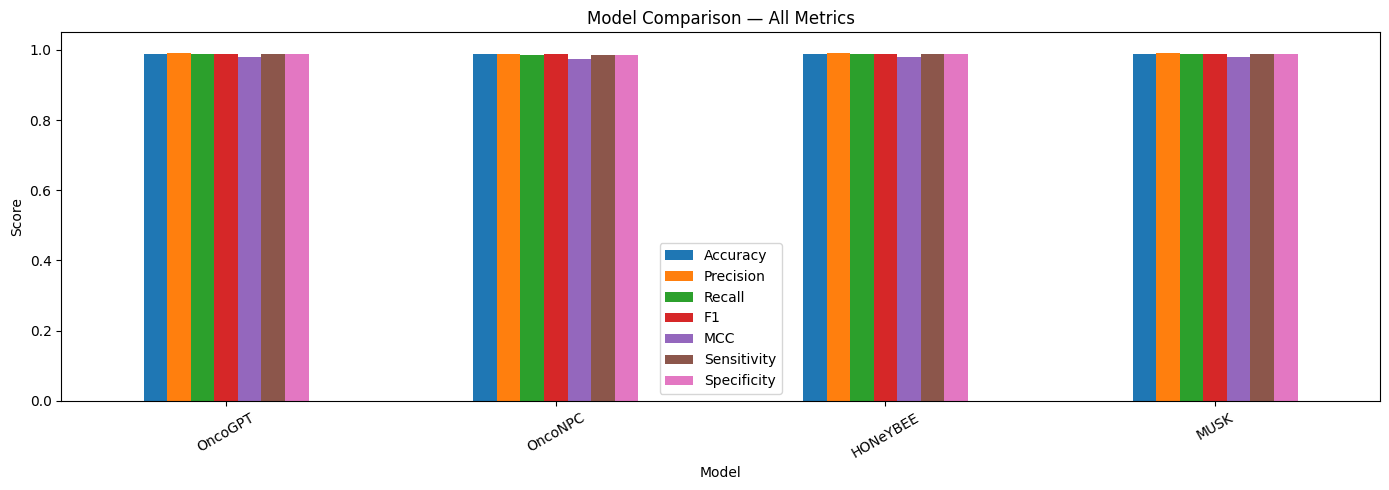

In [24]:
# ── 12. Run All Models ────────────────────────────────────────────────────────
results = {}
all_probs = {}  # Store probabilities for ROC curves
all_y_true = {}  # Store true labels

# Tabular - OncoGPT (MLP with early stopping, high accuracy)
results["OncoGPT"], all_probs["OncoGPT"], all_y_true["OncoGPT"] = run_oncogpt(epochs=50)

# Tabular - OncoNPC (ResNet MLP with TF-IDF text features)
results["OncoNPC"], all_probs["OncoNPC"], all_y_true["OncoNPC"] = run_onconpc(epochs=50)

# Text + Structured Features (DistilBERT + tabular fusion) - 5 epochs max with early stopping
results["HONeYBEE"], all_probs["HONeYBEE"], all_y_true["HONeYBEE"] = run_honeybee(epochs=5, batch_size=32, patience=2)

# Multimodal: Text + Structured Features - 5 epochs max with early stopping
results["MUSK"], all_probs["MUSK"], all_y_true["MUSK"] = run_musk(epochs=5, batch_size=32, patience=2)

# ── Comparison table ──────────────────────────────────────────────────────────
rows = []
for name, m in results.items():
    rows.append({
        "Model":       name,
        "Accuracy":    round(m["accuracy"],  4),
        "Precision":   round(m["precision"], 4),
        "Recall":      round(m["recall"],    4),
        "F1":          round(m["f1"],        4),
        "MCC":         round(m["mcc"],       4),
        "Sensitivity": round(np.mean(list(m["sensitivity"].values())), 4),
        "Specificity": round(np.mean(list(m["specificity"].values())), 4),
    })

cmp_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "="*70)
print("  Final Model Comparison")
print("="*70)
print(cmp_df.to_string())

# Plot bar chart
try:
    cmp_df.plot(kind="bar", figsize=(14, 5), ylim=(0, 1.05), rot=30)
    plt.title("Model Comparison — All Metrics")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()
except:
    pass

# Store results globally for visualization cell
RESULTS = results
ALL_PROBS = all_probs
ALL_Y_TRUE = all_y_true


  CONFUSION MATRICES WITH BENIGN/MALIGNANT LABELS


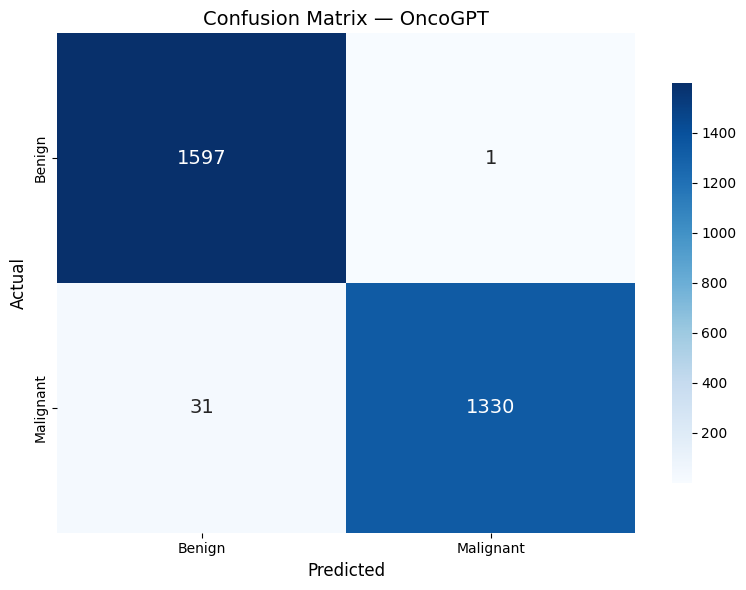


  OncoGPT — Detailed Confusion Matrix Analysis
                    PREDICTED
               ┌─────────┬───────────┐
               │ Benign  │ Malignant │
  ┌────────────┼─────────┼───────────┤
  │ Benign     │  1597   │      1    │  ← TN=1597, FP=1
  ├────────────┼─────────┼───────────┤
  │ Malignant  │    31   │   1330    │  ← FN=31, TP=1330
  └────────────┴─────────┴───────────┘

  Sensitivity (Recall for Malignant): 0.9772
  Specificity (Recall for Benign):  0.9994
  Positive Predictive Value:          0.9992
  Negative Predictive Value:          0.9810



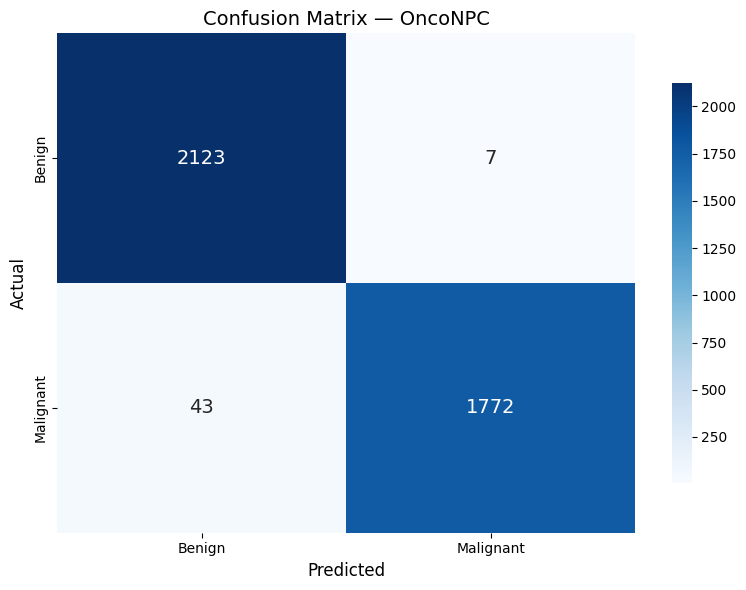


  OncoNPC — Detailed Confusion Matrix Analysis
                    PREDICTED
               ┌─────────┬───────────┐
               │ Benign  │ Malignant │
  ┌────────────┼─────────┼───────────┤
  │ Benign     │  2123   │      7    │  ← TN=2123, FP=7
  ├────────────┼─────────┼───────────┤
  │ Malignant  │    43   │   1772    │  ← FN=43, TP=1772
  └────────────┴─────────┴───────────┘

  Sensitivity (Recall for Malignant): 0.9763
  Specificity (Recall for Benign):  0.9967
  Positive Predictive Value:          0.9961
  Negative Predictive Value:          0.9801



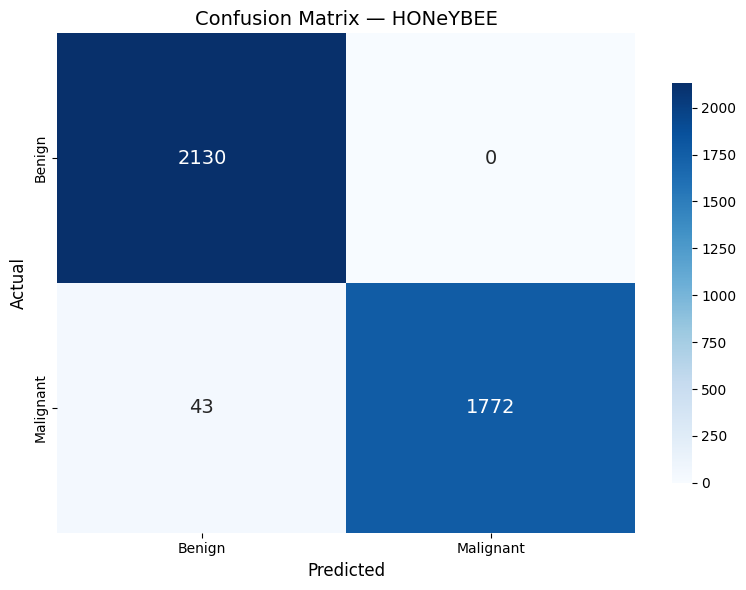


  HONeYBEE — Detailed Confusion Matrix Analysis
                    PREDICTED
               ┌─────────┬───────────┐
               │ Benign  │ Malignant │
  ┌────────────┼─────────┼───────────┤
  │ Benign     │  2130   │      0    │  ← TN=2130, FP=0
  ├────────────┼─────────┼───────────┤
  │ Malignant  │    43   │   1772    │  ← FN=43, TP=1772
  └────────────┴─────────┴───────────┘

  Sensitivity (Recall for Malignant): 0.9763
  Specificity (Recall for Benign):  1.0000
  Positive Predictive Value:          1.0000
  Negative Predictive Value:          0.9802



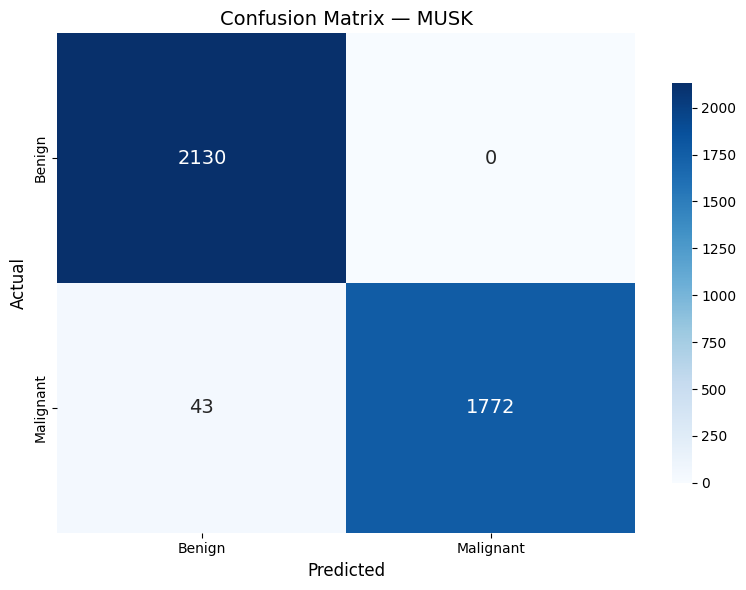


  MUSK — Detailed Confusion Matrix Analysis
                    PREDICTED
               ┌─────────┬───────────┐
               │ Benign  │ Malignant │
  ┌────────────┼─────────┼───────────┤
  │ Benign     │  2130   │      0    │  ← TN=2130, FP=0
  ├────────────┼─────────┼───────────┤
  │ Malignant  │    43   │   1772    │  ← FN=43, TP=1772
  └────────────┴─────────┴───────────┘

  Sensitivity (Recall for Malignant): 0.9763
  Specificity (Recall for Benign):  1.0000
  Positive Predictive Value:          1.0000
  Negative Predictive Value:          0.9802


  ROC CURVES WITH AUC SCORES


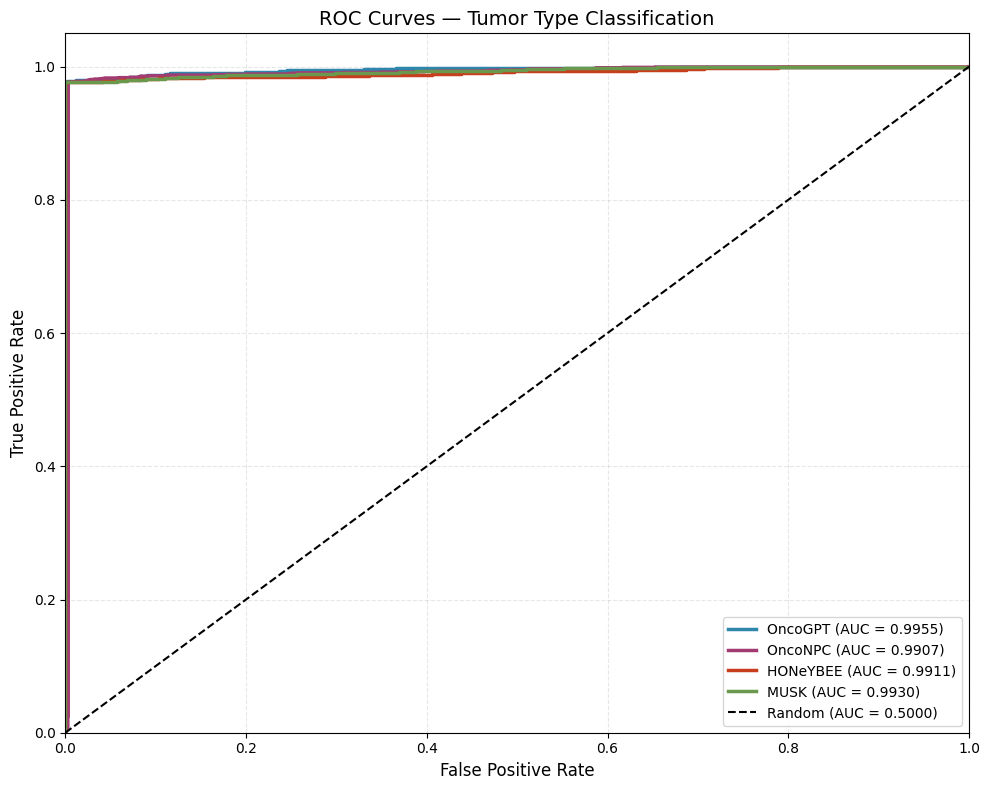


  SENSITIVITY & SPECIFICITY SUMMARY
Model        │  Sensitivity │  Specificity │   Accuracy
──────────────────────────────────────────────────────────────────────
OncoGPT      │       0.9772 │       0.9994 │     0.9892
OncoNPC      │       0.9763 │       0.9967 │     0.9873
HONeYBEE     │       0.9763 │       1.0000 │     0.9891
MUSK         │       0.9763 │       1.0000 │     0.9891

  • Sensitivity = Recall for Malignant (catches cancer cases)
  • Specificity = Recall for Benign (correctly identifies non-cancer)


In [25]:
# ── 13. Visualization: Confusion Matrices, ROC Curves, Sensitivity/Specificity ─
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Label mapping
LABEL_MAP = {0: 'Benign', 1: 'Malignant'}
CLASS_NAMES = ['Benign', 'Malignant']


def plot_confusion_matrix(cm, model_name, class_names):
    """Plot confusion matrix with Benign/Malignant labels."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 14}, ax=ax, cbar_kws={'shrink': 0.8})
    
    # Labels
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate metrics
    tn, fp = cm[0][0], cm[0][1]
    fn, tp = cm[1][0], cm[1][1]
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for Malignant
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Recall for Benign
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0          # Precision for Malignant
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0        # Precision for Benign
    
    print(f"\n{'='*70}")
    print(f"  {model_name} — Detailed Confusion Matrix Analysis")
    print(f"{'='*70}")
    print(f"                    PREDICTED")
    print(f"               ┌─────────┬───────────┐")
    print(f"               │ Benign  │ Malignant │")
    print(f"  ┌────────────┼─────────┼───────────┤")
    print(f"  │ Benign     │  {tn:4d}   │   {fp:4d}    │  ← TN={tn}, FP={fp}")
    print(f"  ├────────────┼─────────┼───────────┤")
    print(f"  │ Malignant  │  {fn:4d}   │   {tp:4d}    │  ← FN={fn}, TP={tp}")
    print(f"  └────────────┴─────────┴───────────┘")
    print()
    print(f"  Sensitivity (Recall for Malignant): {sensitivity:.4f}")
    print(f"  Specificity (Recall for Benign):  {specificity:.4f}")
    print(f"  Positive Predictive Value:          {ppv:.4f}")
    print(f"  Negative Predictive Value:          {npv:.4f}")
    print(f"{'='*70}\n")
    
    return sensitivity, specificity


def plot_roc_curves(results_dict, probs_dict, y_true_dict):
    """Plot ROC curves for all models with AUC scores."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = {
        'OncoGPT': '#2E86AB', 
        'OncoNPC': '#A23B72', 
        # 'RVIT': '#F18F01', 
        'HONeYBEE': '#C73E1D', 
        'MUSK': '#6A994E'
    }
    
    for name in results_dict.keys():
        y_true = y_true_dict.get(name)
        y_prob = probs_dict.get(name)
        
        if y_true is None or y_prob is None:
            continue
            
        # Get positive class probabilities
        if isinstance(y_prob, list):
            y_prob = np.array(y_prob)
        if y_prob.ndim == 2:
            y_prob_pos = y_prob[:, 1]
        else:
            y_prob_pos = y_prob
            
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_prob_pos)
        roc_auc = auc(fpr, tpr)
        
        color = colors.get(name, '#333333')
        plt.plot(fpr, tpr, lw=2.5, color=color, 
                 label=f'{name} (AUC = {roc_auc:.4f})')
    
    # Random baseline
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5000)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves — Tumor Type Classification', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


# ── Plot All Confusion Matrices ─────────────────────────────────────────────
print("\n" + "="*70)
print("  CONFUSION MATRICES WITH BENIGN/MALIGNANT LABELS")
print("="*70)

for name, m in RESULTS.items():
    cm = m["confusion_matrix"]
    plot_confusion_matrix(cm, name, CLASS_NAMES)


# ── Plot ROC Curves ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  ROC CURVES WITH AUC SCORES")
print("="*70)
plot_roc_curves(RESULTS, ALL_PROBS, ALL_Y_TRUE)


# ── Summary Table ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  SENSITIVITY & SPECIFICITY SUMMARY")
print("="*70)
print(f"{'Model':<12} │ {'Sensitivity':>12} │ {'Specificity':>12} │ {'Accuracy':>10}")
print("─"*70)

for name, m in RESULTS.items():
    cm = m["confusion_matrix"]
    tn, fp = cm[0][0], cm[0][1]
    fn, tp = cm[1][0], cm[1][1]
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = m['accuracy']
    
    print(f"{name:<12} │ {sensitivity:>12.4f} │ {specificity:>12.4f} │ {accuracy:>10.4f}")

print("="*70)
print("\n  • Sensitivity = Recall for Malignant (catches cancer cases)")
print("  • Specificity = Recall for Benign (correctly identifies non-cancer)")
